# **Hamiltonian Neural Networks: From Energy Drift to Structure-Preserving Learning**
*Literature Overview & Benchmark — Nonlinear Pendulum as Running Example*

**Running example:** Nonlinear pendulum $H(q,p) = p^2/2 - \cos(q)$, large-angle regime ($q_0 = 2.0$ rad, near separatrix)

---

## **1.1 The Energy Drift Problem**

A standard MLP trained to map $(q,p) \to (\dot{q}, \dot{p})$ is an unconstrained regressor with no mechanism to enforce conservation laws. Per-step errors accumulate, producing trajectories that spiral in or out of phase space:

$$\frac{d}{dt}H(\hat{q}(t), \hat{p}(t)) \neq 0$$

Demonstrated in **Cell 2** — the Baseline MLP visibly violates energy conservation under long-time rollout.

---

## **1.2 Hamiltonian Structure as Inductive Bias (Greydanus et al., 2019)**

Parameterize the *scalar* Hamiltonian $H_\theta(q,p)$ and derive the vector field via the canonical symplectic matrix:

$$\begin{pmatrix} \dot{q} \\ \dot{p} \end{pmatrix} = \nabla H_\theta J^{-1}, \qquad J = \begin{pmatrix} 0 & 1 \\ -1 & 0 \end{pmatrix}$$

The symplectic gradient collapses $2n$ free functions to one scalar's gradient — any trajectory satisfying Hamilton's equations *exactly conserves* $H_\theta$ by construction. Training loss:

$$\mathcal{L}_{\text{HNN}} = \left\|\frac{\partial H_\theta}{\partial p} - \dot{q}\right\|^2 + \left\|\frac{\partial H_\theta}{\partial q} + \dot{p}\right\|^2$$

---

## **1.3 The Derivative Label Problem & the Spline Workaround (David & Mehats, 2023)**

Standard HNNs require explicit $\dot{x}$ labels. Naive finite differences (forward Euler) impose a **non-symplectic numerical bias**: Proposition 1 of David & Mehats (2023) proves no $H_\theta$ can drive the loss to zero — an irremovable lower bound exists.

**Workaround:**
- Using higher-order derivation methods for $\dot{x}_{\text{obs}}$ sampling from original $x_{\text{obs}}$ trajectories. For example, fit a `CubicSpline` to the noisy discrete trajectory and evaluate its analytical first derivative. This reconstructs $\dot{x}_{\text{obs}}$ with $O(h^4)$ accuracy, bypassing finite-difference contamination.
- Embed a symplectic integrator in the loss function of the model, corresponding to the Symplectic HNN variant (David & Mehats, 2023).

---

## **1.4 The Dissipation Limit: Port-Hamiltonian Extensions**

Standard HNNs assume $dH/dt = 0$. For damped/driven systems, the port-Hamiltonian formulation:

$$\dot{x} = [J(x) - R(x)]\,\frac{\partial H}{\partial x} + G(x)\,u(t)$$

where $J = -J^\top$ (interconnection), $R = LL^\top \succeq 0$ (Cholesky dissipation), $G$ (input matrix).
- **pHNN** (Desai, 2021): Separate $H_{\theta_1}$, $F_{\theta_2}(t)$, scalar $N_{\theta_3}$ with L1 parsimony.
- **sPHNN** (Roth, 2025): FICNN Hamiltonian enforces global Lyapunov stability.

---

## **1.5 Dual Paradigm Matrix**

| Paradigm | Given | Unknown | Reference |
|---|---|---|---|
| **Data-Driven Identification** | Trajectories $\{X,t\}$ | Hamiltonian $H_\theta$ | Greydanus 2019 |
| **Equation-Driven Solver** | Known $H(q,p)$ + ICs | Continuous $z(t)$ | Mattheakis 2022 |

---

## **1.6 Literature Landscape**

| Model | System | Symplectic | Data | Key Contribution |
|---|---|---|---|---|
| **HNN** (Greydanus 2019) | Conservative | Yes | $(q,p)$ + $\dot{x}$ | Scalar $H_\theta$ → symplectic gradient |
| **pHNN** (Desai 2021) | Non-conservative | Partial | $(q,p,t)$ + $\dot{x}$ | Decompose $H$, $F(t)$, $N$ |
| **Self-Supervised HNN** (Mattheakis 2022) | Conservative (known $H$) | Exact | None | NN as ODE solver |
| **SHNN** (David & Mehats 2023) | Conservative | Exact (modified $H$) | State pairs $(y_0,y_1)$ | Symplectic training loss |
| **Adaptable HNN** (Han 2021) | Conservative, param-varying | Yes | $\dot{x}$ at $\{\alpha_i\}$ | Parameter input channel |
| **HGN** (Toth 2020) | Conservative (pixels) | Approx. | Pixel sequences | VAE + leapfrog in loop |
| **sPHNN** (Roth 2025) | Non-conservative + stable | No | State pairs or $\dot{x}$ | FICNN → Lyapunov stability |
| **SNO** (Makara 2026) | Conservative PDE | Exact (operator) | Function pairs | Symplectic neural operator |

---

Device: cpu  |  TRAIN_MODE: True
Data: torch.Size([1000, 2])  |  Derivative targets: torch.Size([1000, 2])
  [Baseline] epoch  500  loss 2.7169e-04
  [Baseline] epoch 1000  loss 1.8148e-04
  [Baseline] epoch 1500  loss 1.6059e-04
  [Baseline] epoch 2000  loss 1.5213e-04
  [Baseline] epoch 2500  loss 1.4800e-04
  [Baseline] epoch 3000  loss 1.4689e-04
  [Baseline] epoch 3500  loss 1.4542e-04
  [Baseline] epoch 4000  loss 1.4506e-04
  [Baseline] epoch 4500  loss 1.5649e-04
  [Baseline] epoch 5000  loss 1.4520e-04
Saved: weights_baseline.pt


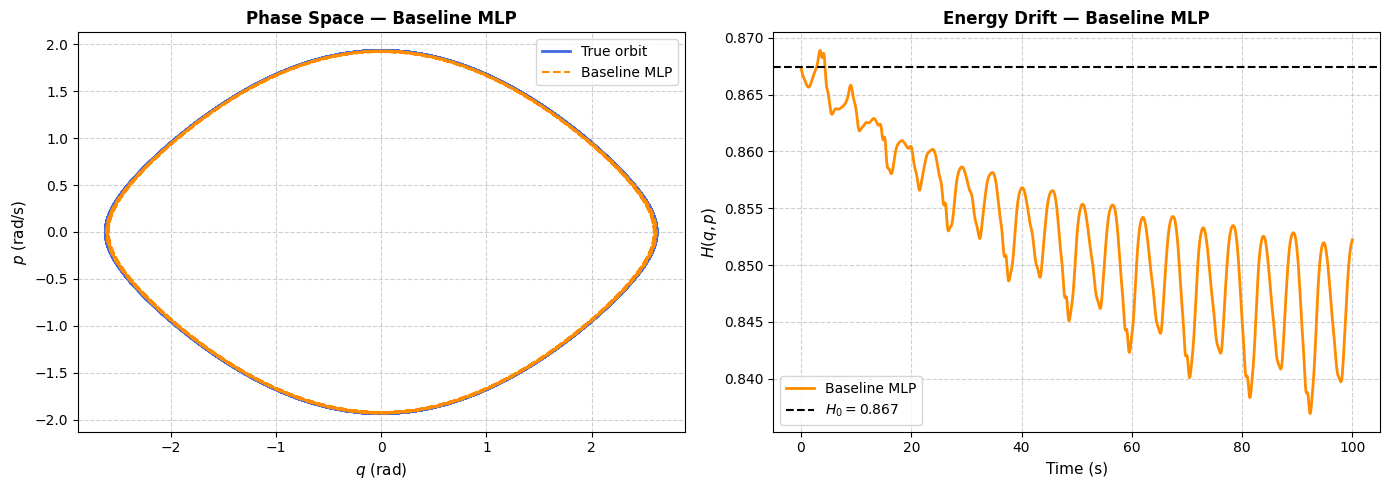

Max |Delta H / H0| Baseline: 3.513%


In [2]:
# ── GLOBAL CONFIGURATION ─────────────────────────────────────────────────────
# Set TRAIN_MODE = True for first run (trains and saves weights).
# Set TRAIN_MODE = False for the live presentation (loads saved weights instantly).
TRAIN_MODE = True

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.interpolate import CubicSpline

torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}  |  TRAIN_MODE: {TRAIN_MODE}')

# ── SYSTEM: NONLINEAR PENDULUM ────────────────────────────────────────────────
# H(q,p) = p^2/2 - cos(q). Oracle used ONLY for data generation — never in training.
def pendulum_rhs(t, y):
    return [y[1], -np.sin(y[0])]

q0, p0       = 2.0, 0.95
T_data, N_pts = 100.0, 1000

sol_gen = solve_ivp(pendulum_rhs, [0, T_data], [q0, p0],
                    t_eval=np.linspace(0, T_data, N_pts),
                    method='RK45', rtol=1e-9, atol=1e-9)
t_data  = sol_gen.t
X_clean = sol_gen.y.T                                          # (500, 2)
X_noisy = X_clean + np.random.randn(*X_clean.shape) * 0.001

# CubicSpline derivative reconstruction — avoids forward-Euler non-symplectic bias
cs        = CubicSpline(t_data, X_noisy)
X_dot_obs = cs(t_data, 1)                                      # (500, 2)

X_t  = torch.tensor(X_noisy,   dtype=torch.float32, device=device)
Xd_t = torch.tensor(X_dot_obs, dtype=torch.float32, device=device)
print(f'Data: {X_t.shape}  |  Derivative targets: {Xd_t.shape}')

# ── BASELINE MLP ─────────────────────────────────────────────────────────────
class BaselineMLP(nn.Module):
    """
    Direct vector field regressor: (q,p) -> (q_dot, p_dot).
    No Hamiltonian structure — no conservation guarantee.
    # EXTEND: Replace forward() with HamiltonianBase.time_derivative() for symplectic bias.
    # CONTRAST: Energy drift compared against HNN in Cell 5.
    """
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 64), nn.Tanh(),
            nn.Linear(64, 64), nn.Tanh(),
            nn.Linear(64, 64), nn.Tanh(),
            nn.Linear(64, 2)
        )
    def forward(self, x):
        return self.net(x)


baseline = BaselineMLP().to(device)

if TRAIN_MODE:
    opt = torch.optim.Adam(baseline.parameters(), lr=1e-3)
    for epoch in range(5000):
        opt.zero_grad()
        loss = F.mse_loss(baseline(X_t), Xd_t)
        loss.backward(); opt.step()
        if (epoch + 1) % 500 == 0:
            print(f'  [Baseline] epoch {epoch+1:4d}  loss {loss.item():.4e}')
    torch.save(baseline.state_dict(), 'weights_baseline.pt')
    print('Saved: weights_baseline.pt')
else:
    baseline.load_state_dict(torch.load('weights_baseline.pt', map_location=device))
    print('Loaded: weights_baseline.pt')
baseline.eval()

# ── ENERGY DRIFT VISUALIZATION ────────────────────────────────────────────────
T_roll = 100.0
t_roll = np.linspace(0, T_roll, 1200)

def baseline_vf(t, y):
    x = torch.tensor([[y[0], y[1]]], dtype=torch.float32, device=device)
    with torch.no_grad():
        dx = baseline(x).cpu().numpy()[0]
    return [float(dx[0]), float(dx[1])]

def H_true(q, p):
    return 0.5 * p**2 - np.cos(q)

sol_base = solve_ivp(baseline_vf, [0, T_roll], [q0, p0], t_eval=t_roll,
                     method='RK45', rtol=1e-4, atol=1e-4, max_step=0.1)
sol_true = solve_ivp(pendulum_rhs, [0, T_roll], [q0, p0], t_eval=t_roll,
                     method='RK45', rtol=1e-9, atol=1e-9)

H0     = H_true(q0, p0)
H_base = H_true(sol_base.y[0], sol_base.y[1])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(sol_true.y[0], sol_true.y[1], color='royalblue', lw=2, label='True orbit')
axes[0].plot(sol_base.y[0], sol_base.y[1], color='darkorange', lw=1.5, ls='--', label='Baseline MLP')
axes[0].set_xlabel(r'$q$ (rad)', fontsize=11); axes[0].set_ylabel(r'$p$ (rad/s)', fontsize=11)
axes[0].set_title('Phase Space — Baseline MLP', fontweight='bold', fontsize=12)
axes[0].legend(); axes[0].grid(True, ls='--', alpha=0.6)

axes[1].plot(sol_base.t, H_base, color='darkorange', lw=2, label='Baseline MLP')
axes[1].axhline(H0, color='black', ls='--', lw=1.5, label=f'$H_0 = {H0:.3f}$')
axes[1].set_xlabel('Time (s)', fontsize=11); axes[1].set_ylabel(r'$H(q,p)$', fontsize=11)
axes[1].set_title('Energy Drift — Baseline MLP', fontweight='bold', fontsize=12)
axes[1].legend(); axes[1].grid(True, ls='--', alpha=0.6)
plt.tight_layout(); plt.show()
print(f'Max |Delta H / H0| Baseline: {np.max(np.abs(H_base - H0)) / abs(H0):.3%}')

  [HNN] epoch  500  loss 3.6487e-04
  [HNN] epoch 1000  loss 2.0406e-04
  [HNN] epoch 1500  loss 1.7238e-04
  [HNN] epoch 2000  loss 1.6157e-04
  [HNN] epoch 2500  loss 1.5473e-04
  [HNN] epoch 3000  loss 1.5046e-04
  [HNN] epoch 3500  loss 1.5236e-04
  [HNN] epoch 4000  loss 2.8641e-04
  [HNN] epoch 4500  loss 1.4650e-04
  [HNN] epoch 5000  loss 1.4664e-04
Saved: weights_hnn.pt


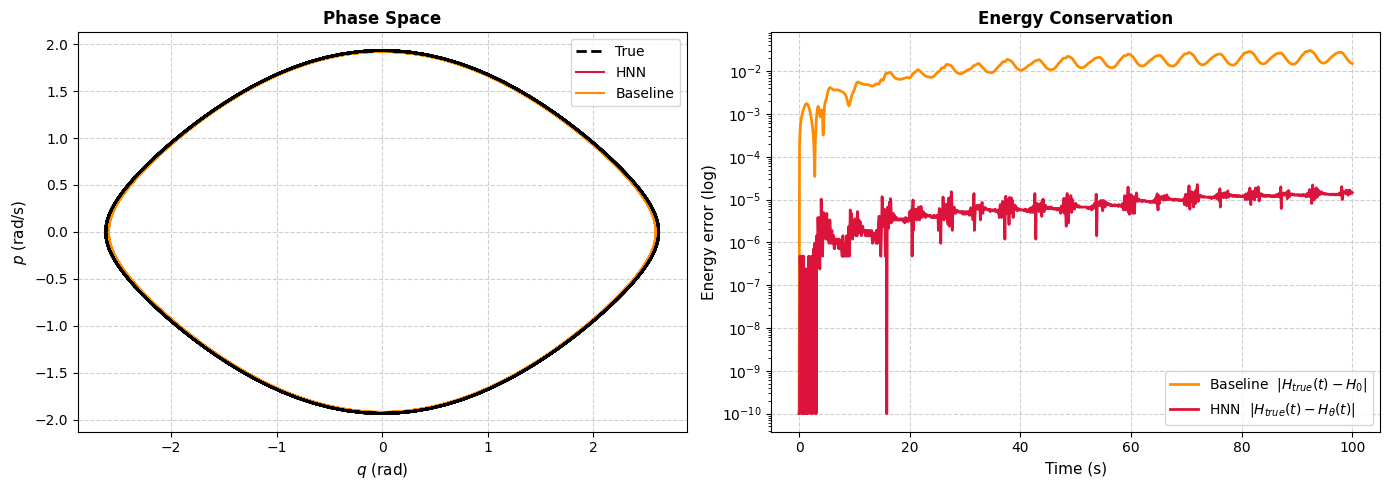

Max |Delta H_theta / H_theta_0| HNN: 0.001%


In [3]:
# ── HAMILTONIAN BASE CLASS ────────────────────────────────────────────────────
class HamiltonianBase(nn.Module):
    """
    Abstract base for all Hamiltonian-structured networks in this framework.
    # EXTEND: Override scalar_field(x) to define H_theta(x).
    # EXTEND: Override time_derivative(x) for non-canonical structures, e.g.,
    #         port-Hamiltonian [J(x)-R(x)] dH/dx for pHNN (Desai 2021).
    # EXTEND: Use FICNN scalar_field (non-neg weights + softplus) for sPHNN
    #         global Lyapunov stability guarantees (Roth 2025).
    """
    def scalar_field(self, x):
        raise NotImplementedError

    def time_derivative(self, x, create_graph=True):
        """Canonical symplectic gradient: [dH/dp, -dH/dq]."""
        x = x.clone().requires_grad_(True)
        H = self.scalar_field(x)
        dH = torch.autograd.grad(
            H.sum(), x, create_graph=create_graph,
            retain_graph=True, only_inputs=True
        )[0]
        return torch.stack([dH[:, 1], -dH[:, 0]], dim=1)

    def get_gradients(self, q_val, p_val):
        """
        Returns (dH/dq, dH/dp) as Python floats for use by custom integrators.
        Two separate evaluations are required by Symplectic Euler's update sequence.
        """
        x = torch.tensor([[q_val, p_val]], dtype=torch.float32, device=device,
                          requires_grad=True)
        H = self.scalar_field(x)
        dH = torch.autograd.grad(H, x)[0].squeeze().detach().cpu().numpy()
        return float(dH[0]), float(dH[1])


# ── HNN ARCHITECTURE (Greydanus et al., 2019) ────────────────────────────────
class HNN(HamiltonianBase):
    """Learns unknown H_theta from trajectory data via spline-reconstructed derivatives."""
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 64), nn.Tanh(),
            nn.Linear(64, 64), nn.Tanh(),
            nn.Linear(64, 64), nn.Tanh(),
            nn.Linear(64, 1)
        )
    def scalar_field(self, x):
        return self.net(x)


hnn = HNN().to(device)

if TRAIN_MODE:
    opt = torch.optim.Adam(hnn.parameters(), lr=1e-3)
    for epoch in range(5000):
        opt.zero_grad()
        loss = F.mse_loss(hnn.time_derivative(X_t), Xd_t)
        loss.backward(); opt.step()
        if (epoch + 1) % 500 == 0:
            print(f'  [HNN] epoch {epoch+1:4d}  loss {loss.item():.4e}')
    torch.save(hnn.state_dict(), 'weights_hnn.pt')
    print('Saved: weights_hnn.pt')
else:
    hnn.load_state_dict(torch.load('weights_hnn.pt', map_location=device))
    print('Loaded: weights_hnn.pt')
hnn.eval()

# ── HELPER UTILITIES ─────────────────────────────────────────────────────────
def make_hnn_vf(model):
    """Wraps a HamiltonianBase as a scipy solve_ivp-compatible vector field."""
    def vf(t, y):
        x = torch.tensor([[y[0], y[1]]], dtype=torch.float32, device=device,
                          requires_grad=True)
        H = model.scalar_field(x)
        dH = torch.autograd.grad(H.sum(), x)[0]
        return [float(dH[0, 1]), float(-dH[0, 0])]
    return vf

def H_theta_np(model, q_arr, p_arr):
    """Evaluates the learned Hamiltonian H_theta along a trajectory."""
    X = torch.tensor(np.stack([q_arr, p_arr], axis=1), dtype=torch.float32, device=device)
    with torch.no_grad():
        out = model.scalar_field(X).cpu().numpy().squeeze()
    return float(out) if out.ndim == 0 else out


# ── PHASE SPACE & ENERGY VISUALIZATION ────────────────────────────────────
hnn_vf  = make_hnn_vf(hnn)
sol_hnn = solve_ivp(hnn_vf, [0, T_roll], [q0, p0], t_eval=t_roll,
                    method='RK45', rtol=1e-6, atol=1e-6)

H_hnn   = H_theta_np(hnn, sol_hnn.y[0], sol_hnn.y[1])
H_hnn_0 = H_theta_np(hnn, np.array([q0]), np.array([p0]))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(sol_true.y[0], sol_true.y[1], color='black',     lw=2,   ls='--', label='True', zorder=3)
axes[0].plot(sol_hnn.y[0],  sol_hnn.y[1],  color='crimson',   lw=1.5, label='HNN')
axes[0].plot(sol_base.y[0], sol_base.y[1], color='darkorange', lw=1.5, label='Baseline')
axes[0].set_xlabel(r'$q$ (rad)', fontsize=11); axes[0].set_ylabel(r'$p$ (rad/s)', fontsize=11)
axes[0].set_title('Phase Space', fontweight='bold', fontsize=12)
axes[0].legend(); axes[0].grid(True, ls='--', alpha=0.6)

axes[1].semilogy(sol_base.t, np.abs(H_base - H0) + 1e-10,
                 color='darkorange', lw=2, label=r'Baseline  $|H_{true}(t)-H_0|$')
axes[1].semilogy(sol_hnn.t,  np.abs(H_hnn  - H_hnn_0) + 1e-10,
                 color='crimson', lw=2, label=r'HNN  $|H_{true}(t)-H_{\theta}(t)|$')
axes[1].set_xlabel('Time (s)', fontsize=11); axes[1].set_ylabel('Energy error (log)', fontsize=11)
axes[1].set_title('Energy Conservation', fontweight='bold', fontsize=12)
axes[1].legend(); axes[1].grid(True, ls='--', alpha=0.6)
plt.tight_layout(); plt.show()
print(f'Max |Delta H_theta / H_theta_0| HNN: {np.max(np.abs(H_hnn - H_hnn_0)) / max(abs(H_hnn_0), 1e-8):.3%}')

## **Cell 3b — Auxiliary: Why Integrator Choice Matters at Inference**

A trained HNN guarantees that the *learned* scalar $H_\theta$ is conserved along the continuous-time flow. At inference, integration reintroduces discretization error. The choice of integrator determines whether this error is **bounded** or **secular**.

### **Backward Error Analysis (Leimkuhler & Reich, 2004)**

A symplectic integrator of order $r$ is the *exact* time-$h$ flow of a **modified Hamiltonian**:

$$\tilde{H} = H_\theta + h^r H_1 + h^{2r} H_2 + \cdots$$

Consequently, the energy error is bounded **uniformly** for all $n$:

$$|H_\theta(z_n) - H_\theta(z_0)| = \mathcal{O}(h^r) \quad \text{for all } n$$

For non-symplectic methods, the bound is $\mathcal{O}(h^r \cdot t)$ — linear **secular drift**.

### **The Counterintuitive Result**

Forward Euler and Symplectic Euler are **both $\mathcal{O}(h)$** — identical accuracy order. Yet their long-time energy behavior is qualitatively different. RK4 is $\mathcal{O}(h^4)$ but still drifts secularly. **Accuracy order does not imply conservation.**

### **Integrator Comparison**

| Integrator | Order | Symplectic | Long-time Energy Error | Literature Connection |
|---|---|---|---|---|
| Forward Euler | 1 | No | $O(h \cdot t)$ — unbounded | Implicit in naive HNN loss |
| Classical RK4 | 4 | No | $O(h^4 \cdot t)$ — secular | Default `solve_ivp` method |
| Symplectic Euler | 1 | Yes | $O(h)$ — bounded | David & Mehats 2023 (training loss) |
| Stormer-Verlet | 2 | Yes | $O(h^2)$ — bounded | HGN leapfrog (Toth 2020) |

**Connection to SHNN:** This observation extends from inference to *training*. The original HNN loss implicitly uses forward Euler, imposing an irremovable lower bound (Prop. 1, David & Mehats 2023). The `# EXTEND:` marker in `HamiltonianBase.time_derivative` marks the upgrade to a symplectic training loss.

Symplectic Euler update sequence (semi-implicit, $O(h)$, symplectic):

$$p_{n+1} = p_n - h\,\frac{\partial H_\theta}{\partial q}(q_n, p_n), \qquad q_{n+1} = q_n + h\,\frac{\partial H_\theta}{\partial p}(q_n, p_{n+1})$$

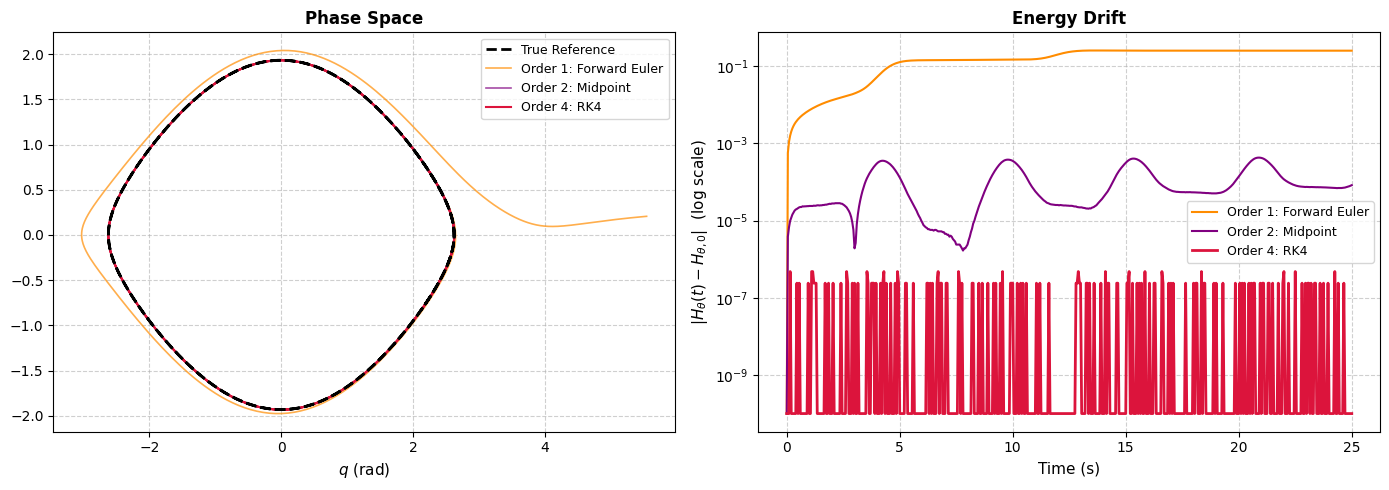

Order 1 Euler      max |H_theta(t) - H_theta_0| = 0.25404930114746094
Order 2 Midpoint   max |H_theta(t) - H_theta_0| = 0.0004265308380126953
SciPy RK45         max |H_theta(t) - H_theta_0| = 4.76837158203125e-07


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# ── FIXED-ORDER RUNGE-KUTTA SUITE & SCIPY INTERFACE ─────────────────────────

def forward_euler(grad_fn, q0, p0, h, n_steps):
    """Non-symplectic, O(h). Baseline failure case."""
    q, p = q0, p0
    qs, ps = [q], [p]
    for _ in range(n_steps):
        dHdq, dHdp = grad_fn(q, p)
        q = q + h * dHdp
        p = p - h * dHdq
        qs.append(q); ps.append(p)
    return np.array(qs), np.array(ps)


def order2_midpoint(grad_fn, q0, p0, h, n_steps):
    """Explicit Midpoint Method, O(h^2)."""
    q, p = q0, p0
    qs, ps = [q], [p]

    for _ in range(n_steps):
        k1_q, k1_p = grad_fn(q, p)

        # Evaluate vector field at the half-step
        q_mid = q + 0.5 * h * k1_p
        p_mid = p - 0.5 * h * k1_q

        _, dHdp_mid = grad_fn(q_mid, p_mid)
        dHdq_mid, _ = grad_fn(q_mid, p_mid)

        q = q + h * dHdp_mid
        p = p - h * dHdq_mid
        qs.append(q); ps.append(p)

    return np.array(qs), np.array(ps)


def rk4_integrator(grad_fn, q0, p0, h, n_steps):
    """Non-symplectic, O(h^4). High accuracy but secular energy drift persists."""
    def f(q, p):
        dHdq, dHdp = grad_fn(q, p)
        return dHdp, -dHdq
    q, p = q0, p0
    qs, ps = [q], [p]
    for _ in range(n_steps):
        k1q, k1p = f(q, p)
        k2q, k2p = f(q + 0.5*h*k1q, p + 0.5*h*k1p)
        k3q, k3p = f(q + 0.5*h*k2q, p + 0.5*h*k2p)
        k4q, k4p = f(q + h*k3q,     p + h*k3p)
        q = q + (h/6) * (k1q + 2*k2q + 2*k3q + k4q)
        p = p + (h/6) * (k1p + 2*k2p + 2*k3p + k4p)
        qs.append(q); ps.append(p)
    return np.array(qs), np.array(ps)


# ── BENCHMARK RUN ────────────────────────────────────────────────────────────
h_b, n_b = 0.05, 500
t_b = np.linspace(0, h_b * n_b, n_b + 1)
gf  = hnn.get_gradients

q_o1, p_o1 = forward_euler(gf, q0, p0, h_b, n_b)
q_o2, p_o2 = order2_midpoint(gf, q0, p0, h_b, n_b)
q_o4, p_o4 = rk4_integrator(gf, q0, p0, h_b, n_b)

# Energy tracking over the learned neural manifold
H_o1 = H_theta_np(hnn, q_o1, p_o1)
H_o2 = H_theta_np(hnn, q_o2, p_o2)
H_o4 = H_theta_np(hnn, q_o4, p_o4)

# Reference orbit
sol_ref_b = solve_ivp(pendulum_rhs, [0, h_b*n_b], [q0, p0],
                      t_eval=t_b, method='RK45', rtol=1e-9, atol=1e-9)

# ── VISUALIZATION ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: Phase Space Comparison
axes[0].plot(sol_ref_b.y[0], sol_ref_b.y[1], color='black', lw=2, ls='--', label='True Reference', zorder=3)
axes[0].plot(q_o1, p_o1, color='darkorange', lw=1.2, alpha=0.7, label='Order 1: Forward Euler')
axes[0].plot(q_o2, p_o2, color='purple',     lw=1.2, alpha=0.7, label='Order 2: Midpoint')
axes[0].plot(q_o4, p_o4, color='crimson',    lw=1.5, label='Order 4: RK4')
axes[0].set_xlabel(r'$q$ (rad)', fontsize=11) 
axes[1].set_ylabel(r'$p$ (rad/s)', fontsize=11)
axes[0].set_title('Phase Space', fontweight='bold', fontsize=12)
axes[0].legend(fontsize=9); axes[1].grid(True, ls='--', alpha=0.6)

# Panel 2: Energy error tracking
axes[1].semilogy(t_b, np.abs(H_o1 - H_hnn_0) + 1e-10, color='darkorange', lw=1.5, label='Order 1: Forward Euler')
axes[1].semilogy(t_b, np.abs(H_o2 - H_hnn_0) + 1e-10, color='purple',     lw=1.5, label='Order 2: Midpoint')
axes[1].semilogy(t_b, np.abs(H_o4 - H_hnn_0) + 1e-10, color='crimson',    lw=2.0, label='Order 4: RK4')
axes[1].set_xlabel('Time (s)', fontsize=11)
axes[1].set_ylabel(r'$|H_\theta(t) - H_{\theta,0}|$  (log scale)', fontsize=11)
axes[1].set_title('Energy Drift', fontweight='bold', fontsize=12)
axes[1].legend(fontsize=9); axes[0].grid(True, ls='--', alpha=0.6)

plt.tight_layout(); plt.show()

# ── PEAK ENERGY ERROR SUMMARY ────────────────────────────────────────────────
for name, H in [('Order 1 Euler', H_o1), ('Order 2 Midpoint', H_o2), ('SciPy RK45', H_o4)]:
    print(f'{name:<18} max |H_theta(t) - H_theta_0| = {np.max(np.abs(H - H_hnn_0))}')

  [SelfSup] epoch 10000  T_cur 25.75  ode 2.7806e-05  energy 1.1368e-04
  [SelfSup] epoch 20000  T_cur 50.50  ode 8.6550e-05  energy 7.8453e-05
  [SelfSup] epoch 30000  T_cur 75.25  ode 8.5147e-07  energy 3.8094e-06
  [SelfSup] epoch 40000  T_cur 100.00  ode 7.0054e-05  energy 1.3945e-05
  [SelfSup] epoch 50000  T_cur 100.00  ode 5.0132e-07  energy 8.5907e-08
Saved: weights_selfsup.pt


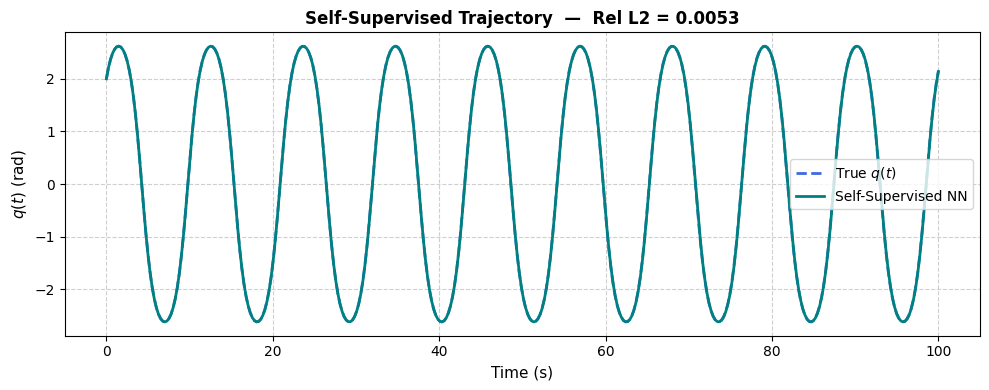

Self-supervised relative L2 on q(t): 0.0053


In [21]:
# ── PARADIGM B: SELF-SUPERVISED EQUATION-DRIVEN SOLVER ───────────────────────
# Mattheakis et al. (2022) — given known H(q,p), discover z(t) without trajectory data.

class Sin(nn.Module):
    """Periodicity-biased activation for oscillatory Hamiltonian systems."""
    def forward(self, x):
        return torch.sin(x)


class TrajectoryNet(nn.Module):
    """
    Maps t -> [q_raw, p_raw]. Wrapped by trial_solution() to enforce ICs.
    # EXTEND: Replace Sin with Tanh for non-oscillatory systems.
    # EXTEND: Generalize trial_solution for multi-dim phase spaces.
    """
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 64), Sin(),
            nn.Linear(64, 64), Sin(),
            nn.Linear(64, 64), Sin(),
            nn.Linear(64, 2)
        )
    def forward(self, t):
        return self.net(t)


z0 = torch.tensor([[q0, p0]], dtype=torch.float32, device=device)  # (1, 2)
E0 = float(0.5 * p0**2 - np.cos(q0))
T_pred, K, lam = 100.0, 2000, 0.1
EPOCHS_SS, WARM_FRAC = 50000, 0.8   # curriculum: ramp window over first 80% of training

def trial_solution(net, t):
    """
    z(t) = z0 + (1 - e^{-t}) * NN(t).
    Satisfies z(0) = z0 exactly at t=0, removing the need for a boundary loss term.
    f(t) = 1 - e^{-t} is bounded (vs f(t)=t which diverges), improving long-time stability.
    """
    return z0 + (1.0 - torch.exp(-t)) * net(t)


traj_net = TrajectoryNet().to(device)

if TRAIN_MODE:
    # Causal / curriculum collocation. Sampling the full [0, T_pred] window from the
    # first epoch drives the optimizer into a spurious near-constant minimum (q -> pi):
    # late-time residuals are driven down before the early-time solution is correct, so
    # no oscillation is ever learned. Growing the window T_cur: 1 -> T_pred fits the
    # trajectory forward in time (Krishnapriyan 2021; Wang 2022), which is required for
    # convergence on this near-separatrix, multi-period orbit.
    opt = torch.optim.Adam(traj_net.parameters(), lr=1e-3)
    n_warm = int(WARM_FRAC * EPOCHS_SS)
    for epoch in range(EPOCHS_SS):
        opt.zero_grad()
        T_cur = 1.0 + (T_pred - 1.0) * min(1.0, (epoch + 1) / n_warm)
        # Stochastic collocation: resample K points in [0, T_cur] each epoch
        t_col = (torch.rand(K, 1, device=device) * T_cur).requires_grad_(True)
        z     = trial_solution(traj_net, t_col)          # (K, 2)
        q_c, p_c = z[:, 0:1], z[:, 1:2]
        # Time derivatives via autograd through the trial function
        dq = torch.autograd.grad(q_c.sum(), t_col, create_graph=True, retain_graph=True)[0]
        dp = torch.autograd.grad(p_c.sum(), t_col, create_graph=True)[0]
        # Hamilton's equations RHS from known H(q,p) = p^2/2 - cos(q):
        #   dq/dt = dH/dp = p      dp/dt = -dH/dq = -sin(q)
        loss_ode = F.mse_loss(dq, p_c) + F.mse_loss(dp, -torch.sin(q_c))
        # Energy conservation regularization: H(q(t), p(t)) ~ E0
        loss_e   = F.mse_loss(0.5*p_c**2 - torch.cos(q_c),
                              torch.full_like(p_c, E0))
        (loss_ode + lam * loss_e).backward()
        opt.step()
        if (epoch + 1) % 10000 == 0:
            print(f'  [SelfSup] epoch {epoch+1:4d}  T_cur {T_cur:4.2f}  ode {loss_ode.item():.4e}  energy {loss_e.item():.4e}')
    torch.save(traj_net.state_dict(), 'weights_selfsup.pt')
    print('Saved: weights_selfsup.pt')
else:
    traj_net.load_state_dict(torch.load('weights_selfsup.pt', map_location=device))
    print('Loaded: weights_selfsup.pt')
traj_net.eval()

# ── TRAJECTORY PREDICTION VISUALIZATION ──────────────────────────────────────
t_ss = np.linspace(0, T_pred, 400)
t_ss_torch = torch.tensor(t_ss.reshape(-1, 1), dtype=torch.float32, device=device)
with torch.no_grad():
    z_ss = trial_solution(traj_net, t_ss_torch).cpu().numpy()
q_ss, p_ss = z_ss[:, 0], z_ss[:, 1]

sol_ref_ss = solve_ivp(pendulum_rhs, [0, T_pred], [q0, p0],
                       t_eval=t_ss, method='RK45', rtol=1e-9, atol=1e-9)

rel_l2_ss = np.linalg.norm(q_ss - sol_ref_ss.y[0]) / (np.linalg.norm(sol_ref_ss.y[0]) + 1e-10)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(t_ss, sol_ref_ss.y[0], color='royalblue', lw=2, ls='--', label=r'True $q(t)$')
ax.plot(t_ss, q_ss,            color='teal',      lw=2, label='Self-Supervised NN')
ax.set_xlabel('Time (s)', fontsize=11); ax.set_ylabel(r'$q(t)$ (rad)', fontsize=11)
ax.set_title(f'Self-Supervised Trajectory  —  Rel L2 = {rel_l2_ss:.4f}', fontweight='bold', fontsize=12)
ax.legend(); ax.grid(True, ls='--', alpha=0.6)
plt.tight_layout(); plt.show()
print(f'Self-supervised relative L2 on q(t): {rel_l2_ss:.4f}')

**Note:** Long Time Rollout, require a curriculum learning schema of the observable input space to ensure learning of the sequencial local features of the trajectory 

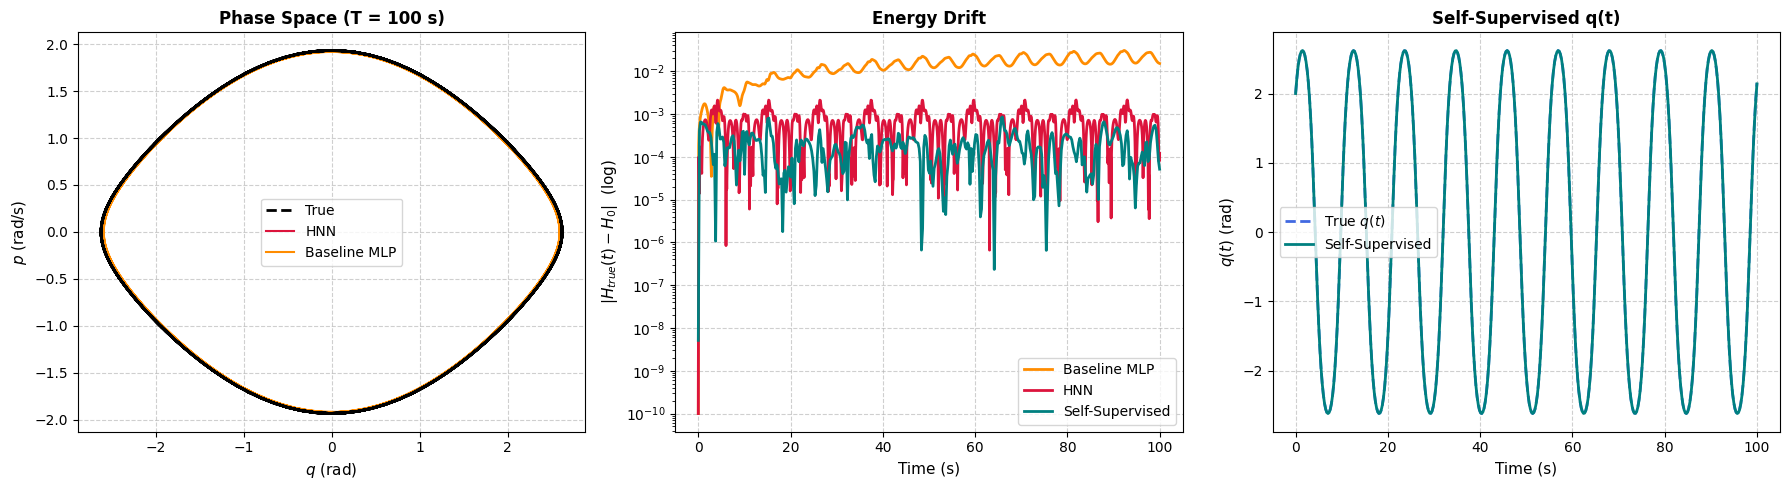

Model                            Train Data                 Rel L2 q(t)    Max |DH|/|H0|   
-------------------------------------------------------------------------------------------
Baseline MLP                     (q,p) + spline x_dot       0.3417         0.0351          
HNN (Greydanus 2019)             (q,p) + spline x_dot       0.0174         0.0025          
Self-Supervised (Mattheakis)     None  —  known H only      0.0053         0.0010          


In [22]:
# ── FINAL BENCHMARK: THREE-MODEL COMPARISON ───────────────────────────────────

# Energy along all trajectories using the true H (consistent comparison)
n_base = len(sol_base.t)
n_hnn  = len(sol_hnn.t)
H_base_true = H_true(sol_base.y[0], sol_base.y[1])
H_hnn_true  = H_true(sol_hnn.y[0],  sol_hnn.y[1])
H_ss_true   = H_true(q_ss, p_ss)

# ── THREE-PANEL FIGURE ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: Phase portrait
axes[0].plot(sol_true.y[0], sol_true.y[1], color='black',     lw=2,   ls='--', label='True', zorder=3)
axes[0].plot(sol_hnn.y[0],  sol_hnn.y[1],  color='crimson',   lw=1.5, label='HNN')
axes[0].plot(sol_base.y[0], sol_base.y[1], color='darkorange', lw=1.5, label='Baseline MLP')
axes[0].set_xlabel(r'$q$ (rad)', fontsize=11); axes[0].set_ylabel(r'$p$ (rad/s)', fontsize=11)
axes[0].set_title('Phase Space (T = 100 s)', fontweight='bold', fontsize=12)
axes[0].legend(); axes[0].grid(True, ls='--', alpha=0.6)

# Panel 2: True energy conservation (same H_true for all — fair comparison)
axes[1].semilogy(sol_base.t, np.abs(H_base_true - H0) + 1e-10, color='darkorange', lw=2, label='Baseline MLP')
axes[1].semilogy(sol_hnn.t,  np.abs(H_hnn_true  - H0) + 1e-10, color='crimson',    lw=2, label='HNN')
axes[1].semilogy(t_ss,       np.abs(H_ss_true   - H0) + 1e-10, color='teal',       lw=2, label='Self-Supervised')
axes[1].set_xlabel('Time (s)', fontsize=11)
axes[1].set_ylabel(r'$|H_{true}(t) - H_0|$  (log)', fontsize=11)
axes[1].set_title('Energy Drift', fontweight='bold', fontsize=12)
axes[1].legend(); axes[1].grid(True, ls='--', alpha=0.6)

# Panel 3: Self-supervised trajectory
axes[2].plot(t_ss, sol_ref_ss.y[0], color='royalblue', lw=2, ls='--', label=r'True $q(t)$')
axes[2].plot(t_ss, q_ss,            color='teal',      lw=2, label='Self-Supervised')
axes[2].set_xlabel('Time (s)', fontsize=11); axes[2].set_ylabel(r'$q(t)$ (rad)', fontsize=11)
axes[2].set_title(f'Self-Supervised q(t)', fontweight='bold', fontsize=12)
axes[2].legend(); axes[2].grid(True, ls='--', alpha=0.6)
plt.tight_layout(); plt.show()

# ── METRICS TABLE ─────────────────────────────────────────────────────────────
rel_l2_base = np.linalg.norm(sol_base.y[0] - sol_true.y[0][:n_base]) / (np.linalg.norm(sol_true.y[0][:n_base]) + 1e-10)
rel_l2_hnn  = np.linalg.norm(sol_hnn.y[0]  - sol_true.y[0][:n_hnn])  / (np.linalg.norm(sol_true.y[0][:n_hnn])  + 1e-10)
max_dH_base = np.max(np.abs(H_base_true - H0)) / max(abs(H0), 1e-8)
max_dH_hnn  = np.max(np.abs(H_hnn_true  - H0)) / max(abs(H0), 1e-8)
max_dH_ss   = np.max(np.abs(H_ss_true   - H0)) / max(abs(H0), 1e-8)

rows = [
    ('Baseline MLP',                '(q,p) + spline x_dot',  f'{rel_l2_base:.4f}', f'{max_dH_base:.4f}'),
    ('HNN (Greydanus 2019)',         '(q,p) + spline x_dot',  f'{rel_l2_hnn:.4f}',  f'{max_dH_hnn:.4f}'),
    ('Self-Supervised (Mattheakis)', 'None  —  known H only', f'{rel_l2_ss:.4f}',   f'{max_dH_ss:.4f}'),
]
hdr = f'{"Model":<32} {"Train Data":<26} {"Rel L2 q(t)":<14} {"Max |DH|/|H0|":<16}'
print(hdr)
print('-' * len(hdr))
for r in rows:
    print(f'{r[0]:<32} {r[1]:<26} {r[2]:<14} {r[3]:<16}')

## **Framework Extension Roadmap**

Each `# EXTEND:` marker in the code above corresponds to a specific literature variant. The table below maps extension points to papers and implementation targets.

| Extension Point | Class / Method | Target Model | Reference |
|---|---|---|---|
| `HamiltonianBase.time_derivative` → `[J(x)-R(x)] dH/dx` | Override | pHNN | Desai et al. 2021 |
| `HamiltonianBase.scalar_field` → FICNN (non-neg weights, softplus) | Override | sPHNN | Roth et al. 2025 |
| `HamiltonianBase` input augmented with parameter $\alpha$ | Subclass | Adaptable HNN | Han et al. 2021 |
| `HNN.time_derivative` loss → symplectic scheme on $(y_0, y_1)$ pairs | Retrain | SHNN | David & Mehats 2023 |
| `symplectic_euler` → `stormer_verlet` (half-kick, drift, half-kick) | Replace fn | HGN inference | Toth et al. 2020 |
| `TrajectoryNet` → neural operator on function space $\mathcal{H}$ | Generalize | SNO | Makara et al. 2026 |

---

### **Key References**

1. Greydanus, Dzamba & Yosinski (2019). *Hamiltonian Neural Networks.* NeurIPS. https://doi.org/10.48550/arXiv.1906.01563
2. Toth et al. (2020). *Hamiltonian Generative Networks.* ICLR. https://doi.org/10.48550/arXiv.1909.13789
3. Desai et al. (2021). *Port-Hamiltonian Neural Networks.* arXiv:2107.08024. https://doi.org/10.48550/arXiv.2107.08024
4. Mattheakis et al. (2022). *Self-Supervised Hamiltonian Neural Networks.* arXiv. https://doi.org/10.48550/arXiv.2001.11107
5. David & Mehats (2023). *Symplectic Learning for Hamiltonian Neural Networks.* ICML. https://doi.org/10.48550/arXiv.2106.11753
6. Roth et al. (2025). *Stable Port-Hamiltonian Neural Networks.* https://doi.org/10.48550/arXiv.2502.02480
7. Makara et al. (2026). *Symplectic Neural Operators.* arXiv. https://doi.org/10.48550/arXiv.2605.15881